In [1]:
# Notebook to create plot scatter plot of the performance metrics of the different methods

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from matplotlib.legend_handler import HandlerLine2D

In [3]:
kg_12=['78.875_24.375', '82.125_23.875', '82.875_27.625', '79.125_23.875','88.875_25.375']
kg_1=['-64.625_0.875', '-73.125_-6.875', '-60.125_-2.375', '-60.625_-4.125', '-66.625_-3.125']
kg_2=['-53.625_-3.625', '-64.125_-6.875', '-55.125_1.375', '-59.875_-7.125', '-72.125_-10.125']
kg_4=['140.125_-33.125',  '143.125_-32.375', '145.125_-29.625', '144.375_-33.625', '144.375_-28.125']
kg_7=['148.125_-29.125', '146.625_-31.375', '146.875_-25.875', '147.125_-27.375', '150.875_-28.125']
kg_26=['26.125_46.875', '18.875_48.625', '15.325_47.625', '19.875_43.325', '16.875_49.375']
kg_14=['16.625_45.875',  '17.625_46.625',  '20.325_44.325', '23.125_43.325', '26.325_42.325']
kg_14_2=['-92.875_37.125', '-93.375_32.625', '-98.125_34.625', '-86.625_35.125', '-82.875_37.125']
kg_25=['-92.875_39.875', '-95.625_42.625', '-88.625_40.125', '-92.875_43.825', '-98.325_42.125'];
kg_zone_list=[kg_1, kg_2, kg_4, kg_7, kg_12, kg_14, kg_14_2, kg_25, kg_26]
kg_zone_names=['kg_1', 'kg_2', 'kg_4', 'kg_7', 'kg_12', 'kg_14', 'kg_14_2', 'kg_25', 'kg_26'];

In [ ]:
varlingam_results_dir='./dircted_adj_results/varlingam_results/';
pcmci_results_dir='./dircted_adj_results/pcmci_results/';
nse_results_dir='./dircted_adj_results/nse_results/';
pearson_results_dir='./dircted_adj_results/pearson_results/';
dynotears_results_dir='./dircted_adj_results/dynotears_results/';
tcdf_results_dir='./dircted_adj_results/tcdf_results/';

In [5]:
zone_wise_results_dict={zone_name:{} for zone_name in kg_zone_names}
for key, zone in zip(zone_wise_results_dict.keys(), kg_zone_list):
    # print(zone, '\n')
    zone_wise_results_dict[key]={grid:{'pearson': {}, 'tcdf': {}, 'varlingam':{}, 'pcmci':{}, 'dynotears': {}} for grid in zone} # , 'tcdf': {}
zone_wise_results_dict

{'kg_1': {'-64.625_0.875': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-73.125_-6.875': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-60.125_-2.375': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-60.625_-4.125': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-66.625_-3.125': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}}},
 'kg_2': {'-53.625_-3.625': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-64.125_-6.875': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-55.125_1.375': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-59.875_-7.125': {'pearson': {},
   'tcdf': {},
   'varlingam': {},
   'pcmci': {},
   'dynotears': {}},
  '-72.125_-1

In [6]:
for key1 in zone_wise_results_dict:
    for key2 in zone_wise_results_dict[key1]:
        # print(key1, key2)
        with open(f'{varlingam_results_dir}{key2}.json', 'r') as f:
            data_varlingam=json.load(f)
        zone_wise_results_dict[key1][key2]['varlingam']=data_varlingam
        with open(f'{pcmci_results_dir}{key2}.json', 'r') as f:
            data_pcmci=json.load(f)
        zone_wise_results_dict[key1][key2]['pcmci']=data_pcmci
        # with open(f'{nse_results_dir}{key2}.json', 'r') as f:
        #     data_nse=json.load(f)
        # zone_wise_results_dict[key1][key2]['nse']=data_nse
        with open(f'{pearson_results_dir}{key2}.json', 'r') as f:
            data_pearson=json.load(f)
        zone_wise_results_dict[key1][key2]['pearson']=data_pearson
        with open(f'{dynotears_results_dir}{key2}.json', 'r') as f:
            data_dynotears=json.load(f)
        zone_wise_results_dict[key1][key2]['dynotears']=data_dynotears
        with open(f'{tcdf_results_dir}{key2}.json', 'r') as f:
            data_tcdf=json.load(f)
        zone_wise_results_dict[key1][key2]['tcdf']=data_tcdf
        del data_varlingam, data_pcmci, data_dynotears, data_pearson,  data_tcdf, # data_nse

In [8]:
df_pearson = pd.DataFrame(columns=['zone'] + list(zone_wise_results_dict['kg_1']['-60.125_-2.375']['pearson'].keys()))
method = 'pearson'
for key1 in zone_wise_results_dict:
    zone = key1
    for key2 in zone_wise_results_dict[key1]:
        new_row = {key_col: zone_wise_results_dict[key1][key2][method][key_col] for key_col in df_pearson.columns[1:]}
        new_row.update({'zone': zone})
        df_pearson = pd.concat([df_pearson, pd.DataFrame(new_row, index=[0])], ignore_index=True)
df_pearson['method'] = method
df_pearson.head()

/tmp/ipykernel_1187164/1460432961.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_pearson = pd.concat([df_pearson, pd.DataFrame(new_row, index=[0])], ignore_index=True)


,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.619,0.101,0.732,0.178,0.326,0.732,0.387,0.613,0.672,0.162,60.0,843.0,533.0,22.0,0.381,1.627,pearson
1,kg_1,0.606,0.097,0.720,0.171,0.314,0.720,0.400,0.600,0.660,0.149,59.0,825.0,551.0,23.0,0.394,1.540,pearson
2,kg_1,0.504,0.074,0.683,0.134,0.259,0.683,0.507,0.493,0.588,0.081,56.0,679.0,697.0,26.0,0.496,1.017,pearson
3,kg_1,0.499,0.084,0.793,0.151,0.294,0.793,0.518,0.482,0.637,0.127,65.0,663.0,713.0,17.0,0.501,0.997,pearson
4,kg_1,0.624,0.106,0.768,0.187,0.342,0.768,0.384,0.616,0.692,0.180,63.0,847.0,529.0,19.0,0.376,1.661,pearson


In [9]:
df_varlingam = pd.DataFrame(columns=['zone'] + list(zone_wise_results_dict['kg_1']['-60.125_-2.375']['varlingam'].keys()))
method = 'varlingam'
for key1 in zone_wise_results_dict:
    zone = key1
    for key2 in zone_wise_results_dict[key1]:
        new_row = {key_col: zone_wise_results_dict[key1][key2][method][key_col] for key_col in df_varlingam.columns[1:]}
        new_row.update({'zone': zone})
        df_varlingam = pd.concat([df_varlingam, pd.DataFrame(new_row, index=[0])], ignore_index=True)
df_varlingam['method'] = method
df_varlingam.head()

/tmp/ipykernel_1187164/3127504359.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_varlingam = pd.concat([df_varlingam, pd.DataFrame(new_row, index=[0])], ignore_index=True)


,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.840,0.142,0.366,0.205,0.278,0.366,0.132,0.868,0.617,0.153,30.0,1195.0,181.0,52.0,0.160,5.258,varlingam
1,kg_1,0.873,0.219,0.488,0.302,0.391,0.488,0.104,0.896,0.692,0.267,40.0,1233.0,143.0,42.0,0.127,6.881,varlingam
2,kg_1,0.843,0.161,0.427,0.234,0.321,0.427,0.132,0.868,0.647,0.191,35.0,1194.0,182.0,47.0,0.157,5.367,varlingam
3,kg_1,0.844,0.174,0.476,0.255,0.353,0.476,0.134,0.866,0.671,0.218,39.0,1191.0,185.0,43.0,0.156,5.395,varlingam
4,kg_1,0.849,0.148,0.354,0.209,0.277,0.354,0.121,0.879,0.616,0.157,29.0,1209.0,167.0,53.0,0.151,5.627,varlingam


In [10]:
df_pcmci = pd.DataFrame(columns=['zone'] + list(zone_wise_results_dict['kg_1']['-60.125_-2.375']['pcmci'].keys()))
method = 'pcmci'
for key1 in zone_wise_results_dict:
    zone = key1
    for key2 in zone_wise_results_dict[key1]:
        new_row = {key_col: zone_wise_results_dict[key1][key2][method][key_col] for key_col in df_pcmci.columns[1:]}
        new_row.update({'zone': zone})#, 'method': method}  )
        df_pcmci = pd.concat([df_pcmci, pd.DataFrame(new_row, index=[0])], ignore_index=True)
df_pcmci['method'] = method
df_pcmci.head()

/tmp/ipykernel_1187164/2024965055.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_pcmci = pd.concat([df_pcmci, pd.DataFrame(new_row, index=[0])], ignore_index=True)


,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.909,0.295,0.439,0.353,0.400,0.439,0.062,0.938,0.688,0.313,36.0,1290.0,86.0,46.0,0.091,10.045,pcmci
1,kg_1,0.909,0.278,0.390,0.325,0.361,0.390,0.060,0.940,0.665,0.282,32.0,1293.0,83.0,50.0,0.091,9.962,pcmci
2,kg_1,0.910,0.283,0.390,0.328,0.363,0.390,0.059,0.941,0.666,0.286,32.0,1295.0,81.0,50.0,0.090,10.130,pcmci
3,kg_1,0.909,0.284,0.402,0.333,0.372,0.402,0.060,0.940,0.671,0.291,33.0,1293.0,83.0,49.0,0.091,10.045,pcmci
4,kg_1,0.911,0.293,0.415,0.343,0.383,0.415,0.060,0.940,0.678,0.302,34.0,1294.0,82.0,48.0,0.089,10.215,pcmci


In [11]:
df_dynotears = pd.DataFrame(columns=['zone'] + list(zone_wise_results_dict['kg_1']['-60.125_-2.375']['dynotears'].keys()))
method = 'dynotears'
for key1 in zone_wise_results_dict:
    zone = key1
    for key2 in zone_wise_results_dict[key1]:
        new_row = {key_col: zone_wise_results_dict[key1][key2][method][key_col] for key_col in df_dynotears.columns[1:]}
        new_row.update({'zone': zone})#, 'method': method}  )
        df_dynotears = pd.concat([df_dynotears, pd.DataFrame(new_row, index=[0])], ignore_index=True)
df_dynotears['method'] = method
df_dynotears.head()

/tmp/ipykernel_1187164/2657033503.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dynotears = pd.concat([df_dynotears, pd.DataFrame(new_row, index=[0])], ignore_index=True)


,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.869,0.234,0.585,0.334,0.450,0.585,0.114,0.886,0.736,0.312,48.0,1219.0,157.0,34.0,0.131,6.634,dynotears
1,kg_1,0.872,0.239,0.585,0.339,0.454,0.585,0.111,0.889,0.737,0.317,48.0,1223.0,153.0,34.0,0.128,6.797,dynotears
2,kg_1,0.871,0.232,0.561,0.329,0.437,0.561,0.110,0.890,0.725,0.303,46.0,1224.0,152.0,36.0,0.129,6.755,dynotears
3,kg_1,0.864,0.190,0.439,0.266,0.348,0.439,0.111,0.889,0.664,0.225,36.0,1223.0,153.0,46.0,0.136,6.327,dynotears
4,kg_1,0.872,0.226,0.524,0.316,0.415,0.524,0.107,0.893,0.709,0.286,43.0,1229.0,147.0,39.0,0.128,6.839,dynotears


In [12]:
df_tcdf = pd.DataFrame(columns=['zone'] + list(zone_wise_results_dict['kg_1']['-60.125_-2.375']['tcdf'].keys()))
method = 'tcdf'
for key1 in zone_wise_results_dict:
    zone = key1
    for key2 in zone_wise_results_dict[key1]:
        new_row = {key_col: zone_wise_results_dict[key1][key2][method][key_col] for key_col in df_tcdf.columns[1:]}
        new_row.update({'zone': zone})#, 'method': method}  )
        df_tcdf = pd.concat([df_tcdf, pd.DataFrame(new_row, index=[0])], ignore_index=True)
df_tcdf['method'] = method
df_tcdf.head()

/tmp/ipykernel_1187164/1378145494.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_tcdf = pd.concat([df_tcdf, pd.DataFrame(new_row, index=[0])], ignore_index=True)


,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.908,0.259,0.341,0.295,0.321,0.341,0.058,0.942,0.642,0.249,28.0,1296.0,80.0,54.0,0.092,9.881,tcdf
1,kg_1,0.901,0.240,0.354,0.286,0.323,0.354,0.067,0.933,0.643,0.240,29.0,1284.0,92.0,53.0,0.099,9.055,tcdf
2,kg_1,0.911,0.255,0.305,0.278,0.293,0.305,0.053,0.947,0.626,0.232,25.0,1303.0,73.0,57.0,0.089,10.215,tcdf
3,kg_1,0.898,0.189,0.244,0.213,0.230,0.244,0.062,0.938,0.591,0.161,20.0,1290.0,86.0,62.0,0.102,8.851,tcdf
4,kg_1,0.899,0.244,0.378,0.297,0.341,0.378,0.070,0.930,0.654,0.252,31.0,1280.0,96.0,51.0,0.101,8.918,tcdf


In [14]:
df=pd.concat([df_pearson, df_tcdf, df_varlingam, df_pcmci, df_dynotears], ignore_index=True)   # df_tcdf  df_nse

,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.619,0.101,0.732,0.178,0.326,0.732,0.387,0.613,0.672,0.162,60.0,843.0,533.0,22.0,0.381,1.627,pearson
1,kg_1,0.606,0.097,0.720,0.171,0.314,0.720,0.400,0.600,0.660,0.149,59.0,825.0,551.0,23.0,0.394,1.540,pearson
2,kg_1,0.504,0.074,0.683,0.134,0.259,0.683,0.507,0.493,0.588,0.081,56.0,679.0,697.0,26.0,0.496,1.017,pearson
3,kg_1,0.499,0.084,0.793,0.151,0.294,0.793,0.518,0.482,0.637,0.127,65.0,663.0,713.0,17.0,0.501,0.997,pearson
4,kg_1,0.624,0.106,0.768,0.187,0.342,0.768,0.384,0.616,0.692,0.180,63.0,847.0,529.0,19.0,0.376,1.661,pearson
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,kg_26,0.831,0.181,0.573,0.276,0.400,0.573,0.154,0.846,0.710,0.253,47.0,1164.0,212.0,35.0,0.169,4.903,dynotears
221,kg_26,0.829,0.167,0.512,0.251,0.362,0.512,0.153,0.847,0.680,0.219,42.0,1166.0,210.0,40.0,0.171,4.832,dynotears
222,kg_26,0.827,0.185,0.610,0.284,0.418,0.610,0.160,0.840,0.725,0.267,50.0,1156.0,220.0,32.0,0.173,4.786,dynotears
223,kg_26,0.812,0.167,0.585,0.259,0.390,0.585,0.174,0.826,0.705,0.238,48.0,1136.0,240.0,34.0,0.188,4.321,dynotears


In [15]:
rgb_codes_names=['No causal link detected', 'Tropical rainforest', 'Tropical monsoon', 
                 'Temperate, dry winter, warm summer', 'Temperate, no dry season, hot summer','Temperate, no dry season, hot summer',
                  'Arid, desert, hot', 'Arid, steppe, cold',
                 'Cold, no dry season, hot summer', 'Cold, no dry season, warm summer' ];
climate_class_basin=['---   ', 'Amazon', 'Amazon', 'Ganga', 'Danube', 'Mississippi', 'Murray', 'Murray', 'Mississippi', 'Danube']
len(rgb_codes_names), len(climate_class_basin)

(10, 10)

In [16]:
# df.to_csv('../../data/violin_df.csv', index=False, sep=',')
df

,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.619,0.101,0.732,0.178,0.326,0.732,0.387,0.613,0.672,0.162,60.0,843.0,533.0,22.0,0.381,1.627,pearson
1,kg_1,0.606,0.097,0.720,0.171,0.314,0.720,0.400,0.600,0.660,0.149,59.0,825.0,551.0,23.0,0.394,1.540,pearson
2,kg_1,0.504,0.074,0.683,0.134,0.259,0.683,0.507,0.493,0.588,0.081,56.0,679.0,697.0,26.0,0.496,1.017,pearson
3,kg_1,0.499,0.084,0.793,0.151,0.294,0.793,0.518,0.482,0.637,0.127,65.0,663.0,713.0,17.0,0.501,0.997,pearson
4,kg_1,0.624,0.106,0.768,0.187,0.342,0.768,0.384,0.616,0.692,0.180,63.0,847.0,529.0,19.0,0.376,1.661,pearson
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,kg_26,0.831,0.181,0.573,0.276,0.400,0.573,0.154,0.846,0.710,0.253,47.0,1164.0,212.0,35.0,0.169,4.903,dynotears
221,kg_26,0.829,0.167,0.512,0.251,0.362,0.512,0.153,0.847,0.680,0.219,42.0,1166.0,210.0,40.0,0.171,4.832,dynotears
222,kg_26,0.827,0.185,0.610,0.284,0.418,0.610,0.160,0.840,0.725,0.267,50.0,1156.0,220.0,32.0,0.173,4.786,dynotears
223,kg_26,0.812,0.167,0.585,0.259,0.390,0.585,0.174,0.826,0.705,0.238,48.0,1136.0,240.0,34.0,0.188,4.321,dynotears


In [17]:
# # Want to dump the results?
# import pickle
# with open('./violin_df.pkl', 'wb') as f:
#     pickle.dump(df, f)

##### Performance metrics

In [18]:
df.columns
# df = df[df['method'] != 'pcmci'];
# df.head()
# methods_order

Index(['zone', 'accuracy', 'precision', 'recall', 'f1', 'fbeta', 'tpr', 'fpr',
       'specificity', 'balanced_acc', 'mcc', 'tp', 'tn', 'fp', 'fn',
       'hamming_distance', 'my_network_metric', 'method'],
      dtype='object')

##### TPR vs FPR

/tmp/ipykernel_1187164/4240067453.py:12: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(data=df, x="fpr", y="tpr", size=df['fp'],


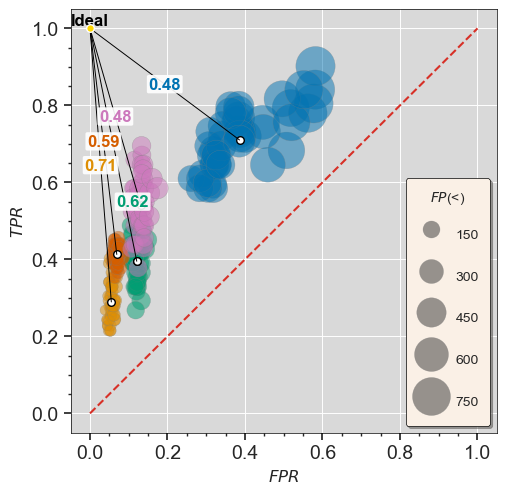

In [ ]:
plt.rcParams["font.family"] = "sans-serif"

fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=100, )    # constrained_layout = True

sns.set_theme(rc={'axes.facecolor':'#d9d9d9', 'figure.facecolor':'white'})  # #f0f0f0  #d9d9d9
sns.scatterplot(data=df, x="fpr", y="tpr", size=df['fp'],
                sizes=(min(df['fp']), max(df['fp'])), 
            palette=sns.color_palette('colorblind'),
                hue="method", legend=True, ax=ax, alpha=0.5, edgecolor='grey', linewidth=0.3, zorder=1)

# Add the "Ideal" point at (0,1)
ax.scatter(0, 1, color='gold', s=30, zorder=4, marker='o', edgecolors='white')  # Point at (0,1)
ax.text(0, 1.0, "Ideal", ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')  # Label above the point

# Get unique methods in the order they appear in `df`
methods_order = df['method'].unique()
# Prepare text for the annotation box
length_texts = []
# Plot the median points and lines from (0,1) to each median point
for i, method in enumerate(methods_order):

    # Calculate the median for each method
    median_fpr = df[df['method'] == method]['fpr'].mean()
    median_tpr = df[df['method'] == method]['tpr'].mean()
    # Plot the median point
    ax.scatter(median_fpr, median_tpr, marker='o', s=30, color='white', edgecolor='black', zorder=3)

    # Calculate the Euclidean distance from (0,1) to the median point
    length = np.sqrt((median_fpr - 0)**2 + (median_tpr - 1)**2)
    length_texts.append(f"{method}: {length:.2f}")
    # print(f"Length from (0,1) to median point ({median_fpr:.2f}, {median_tpr:.2f}) for method '{row['method']}': {length:.2f}")
    # Plot a line from (0,1) to each median point
    ax.plot([0, median_fpr], [1, median_tpr], linestyle='-', alpha=1, linewidth=0.7, zorder=3, color='black')   # color=dict(zip(df['method'].unique(), color_pallette))[method],

    # Annotate the line with its length at the midpoint
    midpoint_x = median_fpr / 2
    midpoint_y = (1 + median_tpr) / 2
    if method == 'varlingam':
        continue
    ax.text(
        midpoint_x, midpoint_y, f"{length:.2f}", 
        # color=dict(zip(df['method'].unique(), color_pallette))[method], fontsize=12,
        color=dict(zip(df['method'].unique(), sns.color_palette('colorblind'),))[method], fontsize=12,
        ha='center', va='center', fontweight='bold', 
        # bbox=None, zorder=15,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, zorder=10, boxstyle='round,pad=0.1'),
    )

# move the varlingam text-box to make it visible
median_fpr = df[df['method'] == 'varlingam']['fpr'].mean()
median_tpr = df[df['method'] == 'varlingam']['tpr'].mean()
# Plot the median point
ax.scatter(median_fpr, median_tpr, marker='o', s=30, color='white', edgecolor='black', zorder=3)
# Calculate the Euclidean distance from (0,1) to the median point
length = np.sqrt((median_fpr - 0)**2 + (median_tpr - 1)**2)
length_texts.append(f"{method}: {length:.2f}")
# Annotate the line with its length at the midpoint
midpoint_x = 0.11 #median_fpr / 2
midpoint_y = 0.55 #(1 + median_tpr) / 2
ax.text(
        midpoint_x, midpoint_y, f"{length:.2f}", 
        color=dict(zip(df['method'].unique(), sns.color_palette('colorblind'),))['varlingam'], fontsize=12,
        ha='center', va='center', fontweight='bold', 
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, zorder=10, boxstyle='round,pad=0.1'),
    )

# Add a diagonal line
ax.plot([0, 1], [0, 1], color='#d73027', linestyle='--', linewidth=1.5, zorder=10, )

# Add minor ticks
ax.minorticks_on()
ax.tick_params(length=2, axis='both', which='both', direction='out', bottom=True, left=True)
ax.tick_params(length=5, axis='both', which='major', direction='out', bottom=True, left=True)

plt.xticks(np.arange(0, 1.1, step=0.2), fontsize=14, weight='normal',)# fontfamily='sans-serif')
plt.yticks(fontsize=14, weight='normal')#, fontfamily='sans-serif')

ax.set_xlabel(r"$\mathit{FPR}$", fontdict={'fontsize': 12, 'style': 'italic', })
ax.set_ylabel(r"$\mathit{TPR}$", fontdict={'fontsize': 12, 'style': 'italic', })

def change_alpha(handle, original):
    ''' Change the alpha and marker style of the legend handles '''
    handle.update_from(original)
    handle.set_alpha(1)
    handle.set_markersize(10)
    # handle.set_marker('.')

handles, labels = ax.get_legend_handles_labels()

legend2 = ax.legend(handles[7:], labels[7:], loc='lower right', fontsize=10, frameon=True, fancybox=True, title="$FP$(<)", title_fontsize=10, 
                   facecolor='linen', edgecolor='black', ncol=1, shadow=True,
                   handleheight=2.7, borderpad=0.8, labelspacing=1 )
legend2.get_frame().set_linewidth(0.5)

ax.grid(True, linestyle="-", linewidth=0.7, color='white', alpha=1, zorder=0)
# ax.set_title('True Positive Ratios vs False Positive Ratios', fontsize=16)

# Add a boundary around the scatterplot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)

# plt.savefig('../../plots/figs/adj_score_figs/summary_figs/tprVSfpr.svg', dpi=400, bbox_inches='tight', pad_inches=0.05)
plt.show()

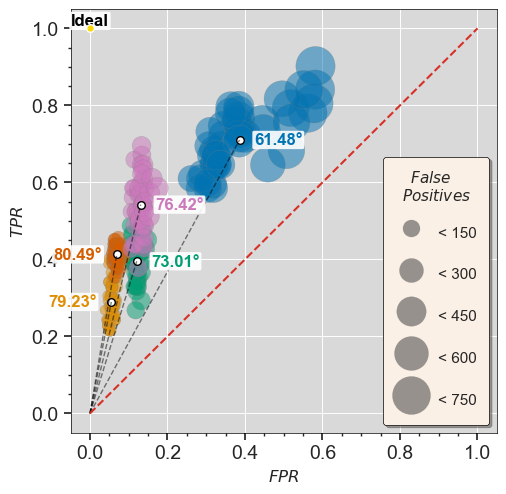

In [ ]:
plt.rcParams["font.family"] = "sans-serif"

fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=100, )    # constrained_layout = True

sns.set_theme(rc={'axes.facecolor': 'd9d9d9', 'figure.facecolor':'white'})  # #f0f0f0  #d9d9d9
sns.scatterplot(data=df, x="fpr", y="tpr", size=df['fp'],
                sizes=(min(df['fp']), max(df['fp'])), 

            palette=sns.color_palette('colorblind', 5),
                hue="method", ax=ax, alpha=0.5, edgecolor='grey', linewidth=0.3, zorder=1,
                legend=True,
                # legend=False,
                )

# Add the "Ideal" point at (0,1)
ax.scatter(0, 1, color='gold', s=30, zorder=4, marker='o', edgecolors='white')  # Point at (0,1)
ax.text(0, 1.0, "Ideal", ha='center', va='bottom', fontsize=12, color='black', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, zorder=10, boxstyle='round,pad=0.1'),
)  # Label above the point

# Get unique methods in the order they appear in `df`
methods_order = df['method'].unique()
# Prepare text for the annotation box
# Plot the median points and lines from (0,1) to each median point
for i, method in enumerate(methods_order):

    # Calculate the median for each method
    median_fpr = df[df['method'] == method]['fpr'].mean()
    median_tpr = df[df['method'] == method]['tpr'].mean()
    # Plot the median point
    ax.scatter(median_fpr, median_tpr, marker='o', s=30, color='white', edgecolor='black', zorder=3)
    
    # Show a line from (0,1) to each median point
    ax.plot([0, median_fpr], [0, median_tpr], linestyle='--', alpha=0.5, linewidth=1, zorder=3, color='black') 

    # Find the angle in degrees
    angle_beta=np.arctan(median_tpr/median_fpr)*180/np.pi   #-45


    if method == 'pcmci' or method == 'tcdf':
        ax.text(
        median_fpr-0.10, median_tpr+0.0, f"{angle_beta:.2f}°", 
        color=dict(zip(df['method'].unique(), sns.color_palette('colorblind', 5),))[method], fontsize=12,
        ha='center', va='center', fontweight='bold', 
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, zorder=10, boxstyle='round,pad=0.1'),
        )
    else:
        ax.text(
        median_fpr+0.10, median_tpr+0.0, f"{angle_beta:.2f}°", 
        color=dict(zip(df['method'].unique(), sns.color_palette('colorblind', 5),))[method], fontsize=12,
        ha='center', va='center', fontweight='bold', 
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, zorder=10, boxstyle='round,pad=0.1'),
        ) 

# Add a diagonal line
ax.plot([0, 1], [0, 1], color='#d73027', linestyle='--', linewidth=1.5, zorder=10, )

# Add minor ticks
ax.minorticks_on()
ax.tick_params(length=2, axis='both', which='both', direction='out', bottom=True, left=True)
ax.tick_params(length=5, axis='both', which='major', direction='out', bottom=True, left=True)

plt.xticks(np.arange(0, 1.1, step=0.2), fontsize=14, weight='normal',)# fontfamily='sans-serif')
plt.yticks(fontsize=14, weight='normal')#, fontfamily='sans-serif')

ax.set_xlabel(r"$\mathit{FPR}$", fontdict={'fontsize': 12, 'style': 'italic', })
ax.set_ylabel(r"$\mathit{TPR}$", fontdict={'fontsize': 12, 'style': 'italic', })

handles, labels = ax.get_legend_handles_labels()
labels=[f'< {label}' for label in labels]
# Second legend for sizes
legend2 = ax.legend(handles[7:], labels[7:], loc='lower right', fontsize=11, frameon=True, fancybox=True, 
                    # title="$FP$(<)", 
                    title="  $False$\n$Positives$",
                    title_fontsize=11, 
                   facecolor='linen', edgecolor='black', ncol=1, shadow=True,
                   handleheight=2.3, borderpad=0.8, labelspacing=1 )
legend2.get_frame().set_linewidth(0.5)

ax.grid(True, linestyle="-", linewidth=0.7, color='white', alpha=1, zorder=0)

# Add a boundary around the scatterplot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)

plt.savefig('../../plots/figs/adj_score_figs/tprVSfpr2.svg', dpi=400, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [21]:
df

,zone,accuracy,precision,recall,f1,fbeta,tpr,fpr,specificity,balanced_acc,mcc,tp,tn,fp,fn,hamming_distance,my_network_metric,method
0,kg_1,0.619,0.101,0.732,0.178,0.326,0.732,0.387,0.613,0.672,0.162,60.0,843.0,533.0,22.0,0.381,1.627,pearson
1,kg_1,0.606,0.097,0.720,0.171,0.314,0.720,0.400,0.600,0.660,0.149,59.0,825.0,551.0,23.0,0.394,1.540,pearson
2,kg_1,0.504,0.074,0.683,0.134,0.259,0.683,0.507,0.493,0.588,0.081,56.0,679.0,697.0,26.0,0.496,1.017,pearson
3,kg_1,0.499,0.084,0.793,0.151,0.294,0.793,0.518,0.482,0.637,0.127,65.0,663.0,713.0,17.0,0.501,0.997,pearson
4,kg_1,0.624,0.106,0.768,0.187,0.342,0.768,0.384,0.616,0.692,0.180,63.0,847.0,529.0,19.0,0.376,1.661,pearson
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,kg_26,0.831,0.181,0.573,0.276,0.400,0.573,0.154,0.846,0.710,0.253,47.0,1164.0,212.0,35.0,0.169,4.903,dynotears
221,kg_26,0.829,0.167,0.512,0.251,0.362,0.512,0.153,0.847,0.680,0.219,42.0,1166.0,210.0,40.0,0.171,4.832,dynotears
222,kg_26,0.827,0.185,0.610,0.284,0.418,0.610,0.160,0.840,0.725,0.267,50.0,1156.0,220.0,32.0,0.173,4.786,dynotears
223,kg_26,0.812,0.167,0.585,0.259,0.390,0.585,0.174,0.826,0.705,0.238,48.0,1136.0,240.0,34.0,0.188,4.321,dynotears


##### MCC

In [ ]:
xtick_labels=['Tropical \nrainforest',
    'Tropical \nmonsoon',
    'Arid, \ndesert, hot',
    'Arid, \nsteppe, cold',
    'Temperate,\ndry winter,\nwarm summer',
    'Temperate,\nno dry season,\nhot summer',
    'Temperate,\nno dry season,\nhot summer',
    'Cold,\nno dry season,\nhot summer',
    'Cold,\nno dry season,\nwarm summer'] 

['Tropical \nrainforest',
 'Tropical \nmonsoon',
 'Arid, \ndesert, hot',
 'Arid, \nsteppe, cold',
 'Temperate,\ndry winter,\nwarm summer',
 'Temperate,\nno dry season,\nhot summer',
 'Temperate,\nno dry season,\nhot summer',
 'Cold,\nno dry season,\nhot summer',
 'Cold,\nno dry season,\nwarm summer']

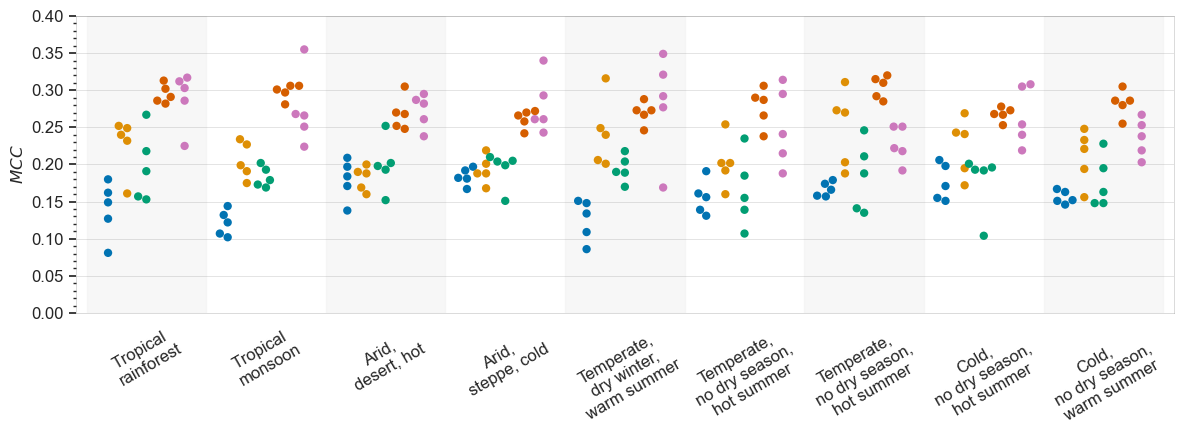

In [ ]:
plt.rcParams["font.family"] = "sans-serif"

sns.set_theme(context='notebook', style='white', font='sans-serif', font_scale=1,)
fig, ax = plt.subplots(figsize=(12, 4.5),)
# ax.set_position([0.2, 0.2, 0.75, 0.75])
g=sns.swarmplot(data=df, x="zone", y="mcc",
              hue="method", legend=False, 
              dodge=True,
            palette=sns.color_palette('colorblind', 5),
            s=6, linewidth=0, alpha=1, ax=ax)

ax.grid(True, linestyle="-", linewidth=0.5, color='grey', alpha=0.3, zorder=-1, axis='y')

# Set left and right margins
ax.margins(x=0.01)
# fig.subplots_adjust(right=0.85)  # This creates space for the legend on the right

ax.set_ylim(0.0, 0.40)
ax.set_yticks(np.arange(0.0, 0.41, step=0.05))

ax.set_xlabel(None)
ax.set_xticks(np.arange(0.0, len(xtick_labels)+0.0, step=1))
ax.set_xticklabels(xtick_labels, rotation=30,  fontsize=12)
ax.set_ylabel(r"$\mathit{MCC}$", fontdict={'fontsize': 12, 'style': 'italic', })
ax.tick_params(axis='y', labelsize=12)
for i in range(len(xtick_labels)):
    if i % 2 == 0:  
        ax.axvspan(i - 0.5, i + 0.5, color='#f0f0f0', alpha=0.5, zorder=0)      # #f0f0f0  #d9d9d9
ax.tick_params(length=5, axis='y', which='major', direction='out', bottom=True, left=True)
plt.yticks(fontsize=12)
ax.minorticks_on()
ax.tick_params(length=2, axis='y', which='minor', direction='out', bottom=True, left=True)
ax.set_title('')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
    spine.set_alpha(0.2)
plt.tight_layout()
fig.savefig('./plots/figs/adj_score_figs/mcc_scores.svg',
            bbox_inches='tight', dpi=400, pad_inches=0.05
            )
plt.show()

##### Cumulative distribution of MCC

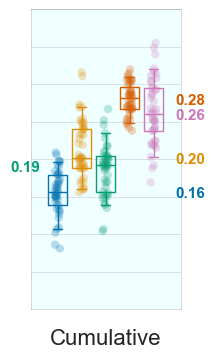

In [ ]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "sans-serif"

sns.set_theme(context='notebook', style='white', font='sans-serif', font_scale=1,)

fig = plt.figure(figsize=(1.5, 3), )
ax = fig.add_axes([0, 0, 1, 1])
ax.set_facecolor('azure')  
g=sns.stripplot(data=df, y="mcc",
              hue="method", legend=False, 
              dodge=True,
            palette=sns.color_palette('colorblind', 5),
            s=6, linewidth=0, alpha=0.25, ax=ax)
sns.boxplot(data=df, y='mcc', ax=ax, hue='method', orient='v', 
            palette=sns.color_palette('colorblind', n_colors=5),
            fill=False, legend=False,
            whis=(5, 95),   # whiskers percentiles
            # whis=(0, 100),   # whiskers percentiles
            width=0.8,     # controls the width of the boxplot 
            linewidth=1,  # controls the linewidth of the boxplot-lines
            fliersize=0,  # controls the size of the fillers
            zorder=1,  # controls the zorder of the boxplot
            gap=0.2,  # controls the gap between the boxplot and the stripplot
            )

ax.grid(True, linestyle="-", linewidth=0.5, color='grey', alpha=0., zorder=0, axis='y')

ax.set_ylim(0.0, 0.40)
ax.set_yticks(np.arange(0.0, 0.41, step=0.05))

ax.xaxis.set_label_position('bottom')
ax.set_xlabel('Cumulative', fontdict={'fontsize': 16, 'style': 'normal', })
ax.set_ylabel(None)
ax.tick_params(bottom=False, left=False, right=False, top=False)
ax.set_title('')

median_vals = df.groupby('method')['mcc'].median()
median_vals=median_vals.reindex(df['method'].unique())
methods = median_vals.index
medians = median_vals.values

# Add yticks at medians
ax.set_yticks(medians)
ax.set_yticklabels([f"{m:.2f}" for m in medians])

# Color each tick label according to palette
for label, color in zip(ax.get_yticklabels(), sns.color_palette('colorblind', n_colors=5)):
    label.set_color(color)
    label.set_fontweight("bold")
    label.set_rotation(0)
    label.set_x(1.25)
# Move only the second last tick label to the left side
yticklabels = ax.get_yticklabels()
second_last_label = yticklabels[-3]
second_last_label.set_x(0.15)

for hline_ in np.arange(0, 0.41, 0.05):
    ax.axhline(y=hline_, color='grey', linestyle='-', linewidth=0.5, alpha=0.3, zorder=0)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
    spine.set_alpha(0.2)
# plt.tight_layout()
fig.savefig('./plots/figs/adj_score_figs/cum_mcc_scores.svg', bbox_inches='tight', dpi=400, pad_inches=0.0)
plt.show()

##### Recall

In [25]:
basin_names=['Amazon', 'Amazon', 'Murray', 'Murray', 'Ganga', 'Danube', 'Mississippi', 'Mississippi', 'Danube'];

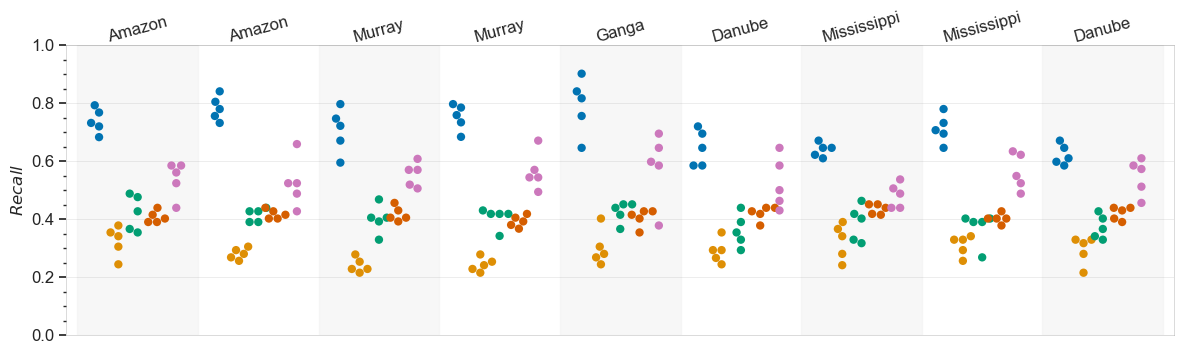

In [ ]:
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(context='notebook', style='white', font='sans-serif', font_scale=1,)
fig, ax = plt.subplots(figsize=(12, 3.7))
g=sns.swarmplot(data=df, x="zone", y="recall",
              hue="method", legend=False, 
              dodge=True,
            palette=sns.color_palette('colorblind', 5),
            s=6, linewidth=0, alpha=1, ax=ax)

ax.grid(True, linestyle="-", linewidth=0.5, color='grey', alpha=0.2, zorder=-1, axis='y')

# Set left and right margins
ax.margins(x=0.01)


ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, step=0.2))

ax.set_xlabel(None)
ax.xaxis.set_ticks_position('top')
ax.set_xticks(np.arange(0.0, len(basin_names)+0.0, step=1))
ax.set_xticklabels(basin_names, rotation=15,  fontsize=12,)
ax.tick_params(pad=-5, length=5, axis='x', which='both', bottom=False, top=False)

ax.set_ylabel(r"$\mathit{Recall}$", fontdict={'fontsize': 12, 'style': 'italic', })
ax.tick_params(axis='y', labelsize=14)

# Add alternating background colors for better readability
for i in range(len(xtick_labels)):
    if i % 2 == 0:  
        ax.axvspan(i - 0.5, i + 0.5, color='#f0f0f0', alpha=0.5, zorder=0)      # #f0f0f0  #d9d9d9

# Adjust the x and y major ticks
ax.tick_params(length=5, axis='y', which='major', direction='out', bottom=True, left=True)
plt.yticks(fontsize=12)

# Add minor ticks
ax.minorticks_on()
ax.tick_params(length=2, axis='y', which='minor', direction='out', bottom=True, left=True)

# ax.set_title('MCC Scores by Zone and Method', fontsize=18)
ax.set_title('')

# Add a boundary around the scatterplot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
    spine.set_alpha(0.2)

plt.tight_layout()
fig.savefig('./plots/figs/adj_score_figs/recall_scores.svg', bbox_inches='tight', dpi=400, pad_inches=0.05)
plt.show()

##### Cumulative distribution of Recall

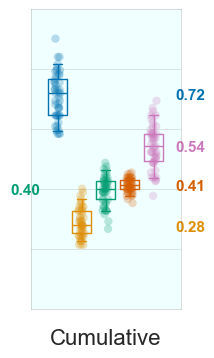

In [ ]:
plt.rcParams["font.family"] = "sans-serif"

sns.set_theme(context='notebook', style='white', font='sans-serif', font_scale=1,)

fig = plt.figure(figsize=(1.5, 3), )
ax = fig.add_axes([0, 0, 1, 1])
ax.set_facecolor('azure')  
g=sns.stripplot(data=df, y="recall",
              hue="method", legend=False, 
              dodge=True,
            palette=sns.color_palette('colorblind', 5),
            s=6, linewidth=0, alpha=0.25, ax=ax)
sns.boxplot(data=df, y='recall', ax=ax, hue='method', orient='v', 
            palette=sns.color_palette('colorblind', n_colors=5),
            fill=False, legend=False,
            whis=(5, 95),   # whiskers percentiles
            # whis=(0, 100),   # whiskers percentiles
            width=0.8,     # controls the width of the boxplot 
            linewidth=1,  # controls the linewidth of the boxplot-lines
            fliersize=0,  # controls the size of the fillers
            zorder=1,  # controls the zorder of the boxplot
            gap=0.2,  # controls the gap between the boxplot and the stripplot
            )

ax.grid(True, linestyle="-", linewidth=0.5, color='grey', alpha=0., zorder=0, axis='y')

ax.set_ylim(0.0, 1)
ax.set_yticks(np.arange(0.0, 1, step=0.2))

ax.xaxis.set_label_position('bottom')
ax.set_xlabel('Cumulative', fontdict={'fontsize': 16, 'style': 'normal', })
ax.set_ylabel(None)
ax.tick_params(bottom=False, left=False, right=False, top=False)
ax.set_title('')

median_vals = df.groupby('method')['recall'].median()
median_vals=median_vals.reindex(df['method'].unique())
methods = median_vals.index
medians = median_vals.values

# Add yticks at medians
ax.set_yticks(medians)
ax.set_yticklabels([f"{m:.2f}" for m in medians])

# Color each tick label according to palette
for label, color in zip(ax.get_yticklabels(), sns.color_palette('colorblind', n_colors=5)):
    label.set_color(color)
    label.set_fontweight("bold")
    label.set_rotation(0)
    label.set_x(1.25)
# Move only the second last tick label to the left side
yticklabels = ax.get_yticklabels()
second_last_label = yticklabels[-3]
second_last_label.set_x(0.15)

for hline_ in np.arange(0, 1, 0.2):
    ax.axhline(y=hline_, color='grey', linestyle='-', linewidth=0.5, alpha=0.3, zorder=0)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
    spine.set_alpha(0.2)
# plt.tight_layout()
fig.savefig('./plots/figs/adj_score_figs/cum_recall_scores.svg', bbox_inches='tight', dpi=400, pad_inches=0.0)
plt.show()